In [1]:
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Statistics
# using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf

include("./read_lidar.jl")
using .read_lidar
# using MAT

using PyPlot

[ Info: Precompiling Revise [295af30f-e4ad-537b-8983-00126c2a3abe] (cache misses: wrong dep version loaded (4), incompatible header (12))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaReviseExt [b74c6c38-2542-566b-9b5f-490bff998244] (cache misses: wrong dep version loaded (4), incompatible header (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
  Activating project at `~/Projects/lidar/ASTRAL2024`
[ Info: Precompiling DSP [717857b8-e6f2-59f4-9121-6e50c889abd2] (cache misses: wrong dep version loaded (2), incompatible header (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling NCDatasets [85f8d34a-cbdd-5861-8df4-14fed0d494ab] (cache misses: wrong dep version loaded (8), incompat

In [2]:
m2n(x) = ismissing(x) ? NaN : x
pd = permutedims

"lidar beam range"
rng(iz, rangegate=24.0) = rangegate * (iz-1 + 0.5)

rng

In [3]:
epsdir = "./epsilon_data"
files = filter(f -> startswith(f, "epsilon_2024") & endswith(f, ".jld2") , readdir(epsdir))

nf = length(files)
epsi = Vector{Matrix{Union{Missing, Float64}}}(undef, nf)
start_dt = Vector{Any}(undef, nf)
end_dt = Vector{Any}(undef, nf)

c = 0
for f in files
    c += 1
    epsi[c] = load(joinpath(epsdir, f))["epsilon"]
end

# load times
c = 0
for f in filter(f -> startswith(f, "staredt_2024") & endswith(f, ".jld2") , readdir(epsdir))
    c += 1
    d = load(joinpath(epsdir, f))
    tmp = d["start_dt"]
    start_dt[c] = tmp
    end_dt[c] = d["end_dt"]
end

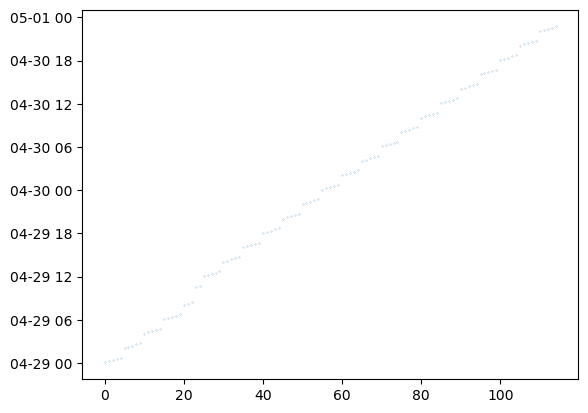

In [ ]:
clf()
plot(start_dt[1], marker=".", markersize=0.3, linestyle="none")
# plot(start_dt[2], marker=".", markersize=0.3, linestyle="none")
gcf()
# spans 2 days rather than 1, so loading all days repeats times!

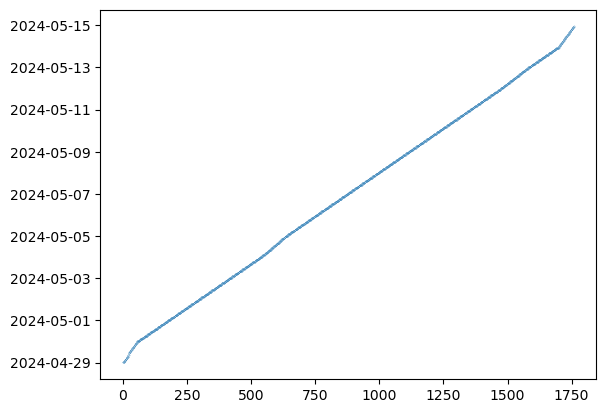

In [ ]:
# # map(x -> cat(x, dims=1), epsi)
# flt(ep) = m2n(ep) >= 0 ? ep : NaN
# nt = size(vcat(epsi...), 1)

# start_time = vcat(start_dt...)
# end_time = vcat(end_dt...)
# # uit = findfirst.(isequal.(unique(start_time)), [start_time]) # already unique
# sit = sortperm(start_time)
# clf()
# plot(start_time[sit], marker=".", markersize=0.3, linestyle="none")
# gcf()

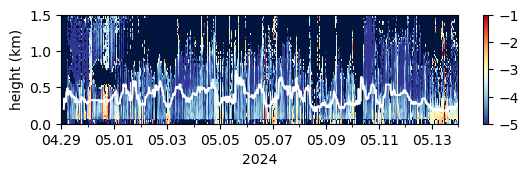

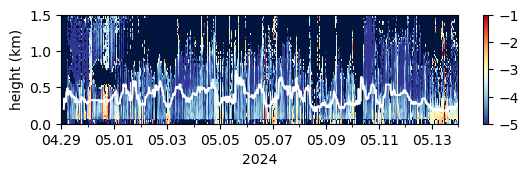

In [13]:
flt(ep) = m2n(ep) >= 0 ? ep : NaN
epsilon_all_plot = vcat(hmix_epsi...)
start_time = vcat(hmix_start_chunks...)
sit = sortperm(start_time)

leg1 = (hmix_start_time .>= DateTime(2024, 4, 29)) .& (hmix_start_time .<= DateTime(2024, 5, 15))

clf()
subplot(3,1,1)
pcolormesh(start_time[sit], rng.(1:80)/1e3, log10.(pd(flt.(epsilon_all_plot)[sit,:])), cmap=ColorMap("RdYlBu_r"), vmin=-5, vmax=-1)
plot(hmix_start_time[leg1], coalesce.(hmix_height_filt_m[leg1], NaN) ./ 1e3, color="w", linewidth=1.4)
colorbar(ticks = -1:-1:-5)
ylim([0, 1.5])
ylabel("height (km)")
xlim([Date(2024,4,29), Date(2024,5,14)])
xlabel("2024")

ax = gca()
ax.xaxis.set_major_formatter(PyPlot.matplotlib.dates.DateFormatter("%m.%d"))
mx = PyPlot.matplotlib.ticker.MultipleLocator(1)
ax.xaxis.set_minor_locator(mx)
ax.set_facecolor("xkcd:navy")

savefig("epsilon_leg1.pdf")
gcf()


In [5]:
f = files[2]
epsi = load(joinpath(epsdir, f))["epsilon"]

clf()
pcolormesh((1:size(epsi,1))*24/115, rng.(1:80)/1e3, log10.(pd(m2n.(epsi))), cmap=ColorMap("RdYlBu_r"))
colorbar()
xlabel("time, hour-ish")
ylabel("height (km)")

PyObject Text(0, 0.5, 'height (km)')

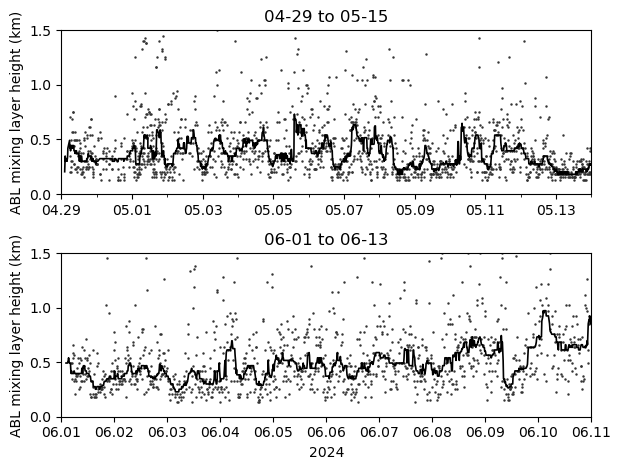

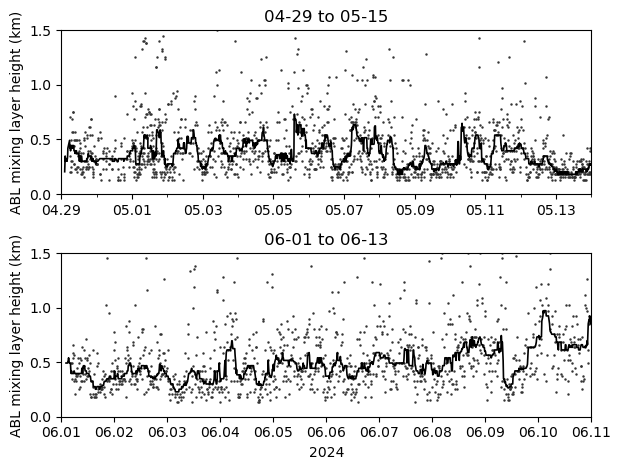

In [16]:
# concatenate all profiles in time, compute h_mix above 100 m, and plot the result by contiguous batch
hmix_files = sort(filter(f -> startswith(f, "epsilon_2024") & endswith(f, ".jld2"), readdir(epsdir)))
hmix_epsi = Matrix{Union{Missing, Float64}}[]
hmix_start_chunks = Vector{Any}[]
hmix_end_chunks = Vector{Any}[]

for f in hmix_files
    d = load(joinpath(epsdir, f))
    push!(hmix_epsi, d["epsilon"])
    push!(hmix_start_chunks, d["start_dt"])
    push!(hmix_end_chunks, d["end_dt"])
end

epsilon_all = vcat(hmix_epsi...)
hmix_start_time = vcat(hmix_start_chunks...)
hmix_end_time = vcat(hmix_end_chunks...)
hmix_sort = sortperm(hmix_start_time)

is_valid_eps(x) = !ismissing(x) && isfinite(x) && x > 0

function hmix_first_crossing(profile; min_valid_below=1, min_height_m=100.0)
    search_start = findfirst(iz -> rng(iz) >= min_height_m, eachindex(profile))
    isnothing(search_start) && return missing

    for iz in (search_start + 1):length(profile)
        eps_i = profile[iz]
        is_valid_eps(eps_i) || continue

        below_vals = [profile[j] for j in search_start:(iz - 1) if is_valid_eps(profile[j])]
        length(below_vals) >= min_valid_below || continue

        if eps_i <= mean(below_vals) / 3
            return iz
        end
    end

    return missing
end

function moving_median_missing(x; half_window=12)
    y = Vector{Union{Missing, Float64}}(missing, length(x))
    for i in eachindex(x)
        i1 = max(firstindex(x), i - half_window)
        i2 = min(lastindex(x), i + half_window)
        vals = collect(skipmissing(x[i1:i2]))
        isempty(vals) && continue
        y[i] = median(vals)
    end
    y
end

hmix_index = [hmix_first_crossing(view(epsilon_all, it, :); min_height_m=100.0) for it in axes(epsilon_all, 1)]
hmix_height_m = Union{Missing, Float64}[ismissing(iz) ? missing : rng(iz) for iz in hmix_index]

hmix_index = hmix_index[hmix_sort]
hmix_height_m = hmix_height_m[hmix_sort]
hmix_start_time = hmix_start_time[hmix_sort]
hmix_end_time = hmix_end_time[hmix_sort]

hmix_windows = [
    (DateTime(2024, 4, 29), DateTime(2024, 5, 14), "04-29 to 05-15"),
    (DateTime(2024, 6, 1), DateTime(2024, 6, 11), "06-01 to 06-13"),
]

hmix_height_filt_m = Vector{Union{Missing, Float64}}(missing, length(hmix_height_m))
for (t1, t2, _) in hmix_windows
    mask = (hmix_start_time .>= t1) .& (hmix_start_time .<= t2)
    hmix_height_filt_m[mask] = moving_median_missing(hmix_height_m[mask]; half_window=12)
end

clf()
for (ipanel, (t1, t2, label)) in enumerate(hmix_windows)
    subplot(2, 1, ipanel)
    mask = (hmix_start_time .>= t1) .& (hmix_start_time .<= t2)
    plot(hmix_start_time[mask], coalesce.(hmix_height_m[mask], NaN) ./ 1e3, linestyle="none", marker=".", markersize=1.5, color="0.2")
    plot(hmix_start_time[mask], coalesce.(hmix_height_filt_m[mask], NaN) ./ 1e3, color="k", linewidth=1.2)
    ylabel("ABL mixing layer height (km)")
    xlim([t1, t2])
    ylim([0, 1.5])
    title(label)

    ax = gca()
    ax.xaxis.set_major_formatter(PyPlot.matplotlib.dates.DateFormatter("%m.%d"))
    mx = PyPlot.matplotlib.ticker.MultipleLocator(1)
    ax.xaxis.set_minor_locator(mx)
end

xlabel("2024")
tight_layout()
gcf()

Composite bin diagnostics:
  Total bins: 40
  Non-empty bins: 40
  Min/median/max sample count: 1034 / 1931.0 / 3475


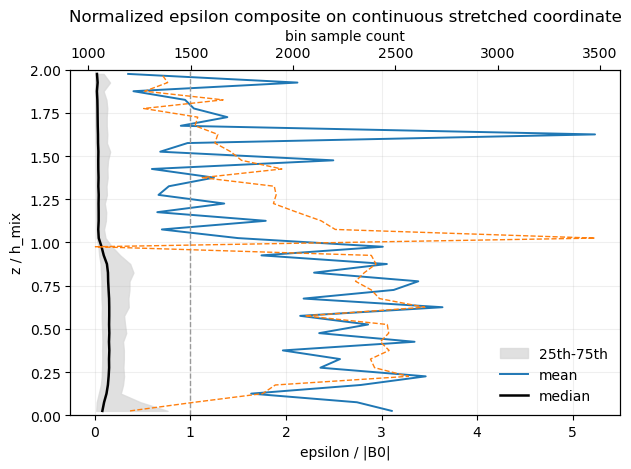

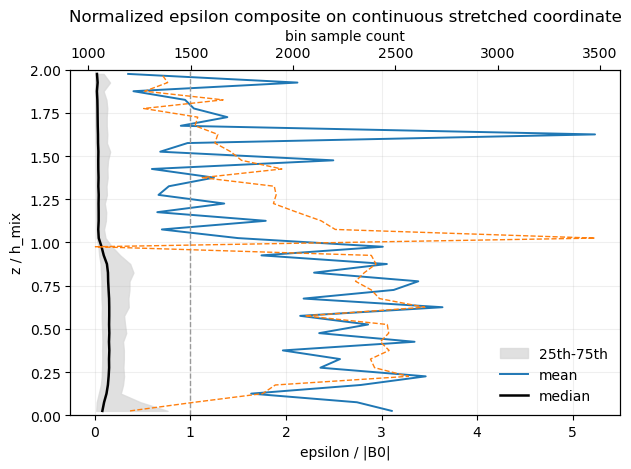

In [22]:
# normalize epsilon by surface buoyancy flux and composite on stretched coordinate around h_mix
psl_files = [
    "/mnt/c/Users/deszoeks/Data/EKAMSAT/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
    "/Users/deszoeks/Data/EKAMSAT/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
    "/Users/deszoeks/Projects/ASTRAL/SSTcompare/data/PSL/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
]
psl_idx = findfirst(isfile, psl_files)
psl_idx === nothing && error("No PSL met file found in psl_files.")
psl_file = psl_files[psl_idx]
psl = NCDataset(psl_file)

"compute surface buoyancy flux in m^2 s^-3 from PSL met data"
function calc_bflx(t, q, hs_bulk, hl_bulk, rho)
    Cp = 1005.0
    L = 2.4e6
    g = 9.8
    hs = -hs_bulk
    hl = -hl_bulk
    wt = hs ./ (rho * Cp)
    wq = hl ./ (rho * L)
    fac = @. 1 + 0.608 * q
    fac2 = 0.608 ./ fac
    @. g * (wt / t + fac2 * wq)
end

psl_time_raw = psl[:time][:]
bflx0 = calc_bflx(psl[:tskin][:] .+ 273.15, psl[:qskin][:] .* 1e-3, psl[:hs_bulk][:], psl[:hl_bulk][:], psl[:rhoair][:])

# retain only valid PSL timestamps for nearest-neighbor time matching
psl_valid = findall(t -> !ismissing(t), psl_time_raw)
psl_time = DateTime[psl_time_raw[i] for i in psl_valid]

function nearest_time_index(tvec::AbstractVector{DateTime}, t::DateTime)
    i = searchsortedfirst(tvec, t)
    if i <= 1
        return 1
    elseif i > length(tvec)
        return length(tvec)
    else
        return abs(tvec[i] - t) < abs(tvec[i - 1] - t) ? i : (i - 1)
    end
end

# map each epsilon profile time to nearest PSL buoyancy-flux time
# guard against cross-leg matching by requiring nearby times
max_match_minutes = 120.0
bflx_at_profile = Vector{Union{Missing, Float64}}(missing, length(hmix_start_time))
for i in eachindex(hmix_start_time)
    ip_valid = nearest_time_index(psl_time, hmix_start_time[i])
    dt_minutes = abs(Dates.value(psl_time[ip_valid] - hmix_start_time[i])) / 60000.0
    if dt_minutes > max_match_minutes
        continue
    end
    ip = psl_valid[ip_valid]
    b = bflx0[ip]
    bflx_at_profile[i] = (ismissing(b) || !isfinite(b)) ? missing : b
end

# stretched coordinate: 20 levels between surface and h_mix, plus 20 levels above h_mix
eta_edges = collect(range(0.0, 2.0, length=41))
eta_centers = 0.5 .* (eta_edges[1:end-1] .+ eta_edges[2:end])

bin_vals = [Float64[] for _ in eachindex(eta_centers)]

for it in axes(epsilon_all, 1)
    hm = hmix_height_m[it]
    b0 = bflx_at_profile[it]
    if ismissing(hm) || ismissing(b0) || hm <= 0 || abs(b0) <= 1e-8
        continue
    end

    prof = view(epsilon_all, it, :)
    for iz in eachindex(prof)
        epsv = prof[iz]
        if ismissing(epsv) || !isfinite(epsv) || epsv <= 0
            continue
        end

        eta = rng(iz) / hm
        if eta < eta_edges[1] || eta > eta_edges[end]
            continue
        end

        ib = searchsortedlast(eta_edges, eta)
        if ib == length(eta_edges)
            ib -= 1
        end
        if ib < 1 || ib > length(eta_centers)
            continue
        end

        push!(bin_vals[ib], epsv / abs(b0))
    end
end

cnt_eta = [length(v) for v in bin_vals]
mean_eta = fill(NaN, length(eta_centers))
median_eta = fill(NaN, length(eta_centers))
q25_eta = fill(NaN, length(eta_centers))
q75_eta = fill(NaN, length(eta_centers))

for ib in eachindex(bin_vals)
    vals = bin_vals[ib]
    isempty(vals) && continue
    mean_eta[ib] = mean(vals)
    median_eta[ib] = median(vals)
    q25_eta[ib] = quantile(vals, 0.25)
    q75_eta[ib] = quantile(vals, 0.75)
end

println("Composite bin diagnostics:")
println("  Total bins: ", length(eta_centers))
println("  Non-empty bins: ", count(>(0), cnt_eta))
println("  Min/median/max sample count: ", minimum(cnt_eta), " / ", median(cnt_eta), " / ", maximum(cnt_eta))

clf()
fill_betweenx(eta_centers, q25_eta, q75_eta, color="0.85", alpha=0.8, label="25th-75th")
semilogx(mean_eta, eta_centers, color="tab:blue", linewidth=1.4, label="mean")
plot(median_eta, eta_centers, color="k", linewidth=1.8, label="median")
axvline(1.0, color="0.6", linewidth=1.0, linestyle="--")
xlabel("epsilon / |B0|")
ylabel("z / h_mix")
title("Normalized epsilon composite on continuous stretched coordinate")
ylim([0, 2])
grid(alpha=0.2)
legend(frameon=false, loc="best")

axc = twiny()
axc.plot(cnt_eta, eta_centers, color="tab:orange", linewidth=1.0, linestyle="--")
axc.set_xlabel("bin sample count")

tight_layout()
gcf()

In [24]:
# Diagnostic: check for inf, nan, and negative values in bin_vals
all_vals = vcat(bin_vals...)
n_inf = count(isinf, all_vals)
n_nan = count(isnan, all_vals)
n_neg = count(<(0), all_vals)
n_zero = count(==(0), all_vals)

println("\nDiagnostics for bin_vals:")
println("  Total values: ", length(all_vals))
println("  Inf values: ", n_inf)
println("  NaN values: ", n_nan)
println("  Negative values: ", n_neg)
println("  Zero values: ", n_zero)
println("  Min value: ", minimum(all_vals))
println("  Max value: ", maximum(all_vals))
println("  25th percentile: ", quantile(all_vals, 0.25))
println("  Median: ", median(all_vals))
println("  Mean: ", mean(all_vals))
println("  75th percentile: ", quantile(all_vals, 0.75))
println("  95th percentile: ", quantile(all_vals, 0.95))

# Check if very small b0 values are creating large epsilon/|b0| ratios
println("\nDiagnostics for bflx_at_profile:")
valid_bflx = collect(skipmissing(bflx_at_profile))
println("  Non-missing values: ", length(valid_bflx))
println("  Min |B0|: ", minimum(abs, valid_bflx))
println("  Max |B0|: ", maximum(abs, valid_bflx))
println("  Median |B0|: ", median(abs.(valid_bflx)))

# Count how many extreme (>1) normalized values there are
n_gt1 = count(>(1.0), all_vals)
n_gt10 = count(>(10.0), all_vals)
println("\n  Values > 1: ", n_gt1, " (", round(100*n_gt1/length(all_vals), digits=2), "%)")
println("  Values > 10: ", n_gt10, " (", round(100*n_gt10/length(all_vals), digits=2), "%)")


Diagnostics for bin_vals:
  Total values: 79386
  Inf values: 0
  NaN values: 0
  Negative values: 0
  Zero values: 0
  Min value: 2.141847116886982e-7
  Max value: 5879.916416211056
  25th percentile: 0.02874327643579985
  Median: 0.08761622306621478
  Mean: 2.059739278773758
  75th percentile: 0.24518649486253397
  95th percentile: 3.0873938814382145

Diagnostics for bflx_at_profile:
  Non-missing values: 4567
  Min |B0|: 3.79993311302412e-5
  Max |B0|: 0.004680238744242482
  Median |B0|: 0.00036342788009325586

  Values > 1: 7979 (10.05%)
  Values > 10: 1304 (1.64%)



=== Positive B0 (Unstable) with Filter B0 >= 1e-4 ===
Total values: 78420
Non-empty bins: 40
Min/median/max sample count: 1023 / 1906.5 / 3435
Min/median/max epsilon/B0: 2.141847116886982e-7 / 0.08678754665134167 / 5879.916416211056

=== Negative B0 (Stable) with Filter B0 >= 1e-4 ===
Total values: 0
No stable (B0<0) data found!

=== Buoyancy Flux Filter Impact ===
Before filter: Min=3.79993311302412e-5, Max=0.004680238744242482, Count=4567
After filter (B0 >= 1e-4): Min=0.00010100194322600811, Median=0.000365605103434279, Max=0.004680238744242482, Count=4500
Profiles removed: 67 (1.5%)


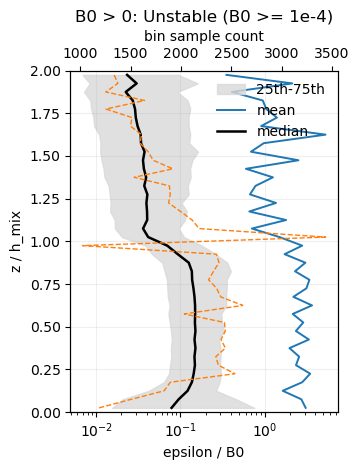

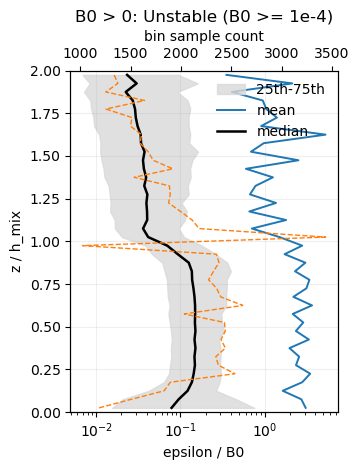

In [32]:
# Separate composites for B0>0 (unstable) and B0<0 (stable)
# Include epsilon from ALL heights (no 100m minimum)
# Filter: exclude profiles where B0 < 1e-4 (weak buoyancy flux)

eta_edges = collect(range(0.0, 2.0, length=41))
eta_centers = 0.5 .* (eta_edges[1:end-1] .+ eta_edges[2:end])

bin_vals_pos = [Float64[] for _ in eachindex(eta_centers)]  # B0 > 0 (unstable)
bin_vals_neg = [Float64[] for _ in eachindex(eta_centers)]  # B0 < 0 (stable)

min_b0_filter = 1e-4

for it in axes(epsilon_all, 1)
    hm = hmix_height_m[it]
    b0 = bflx_at_profile[it]
    
    if ismissing(hm) || ismissing(b0) || hm <= 0 || abs(b0) < min_b0_filter
        continue
    end

    prof = view(epsilon_all, it, :)
    for iz in eachindex(prof)
        epsv = prof[iz]
        if ismissing(epsv) || !isfinite(epsv) || epsv <= 0
            continue
        end

        eta = rng(iz) / hm
        if eta < eta_edges[1] || eta > eta_edges[end]
            continue
        end

        ib = searchsortedlast(eta_edges, eta)
        if ib == length(eta_edges)
            ib -= 1
        end
        if ib < 1 || ib > length(eta_centers)
            continue
        end

        normalized = epsv / b0  # no abs() - preserve sign

        if b0 > 0
            push!(bin_vals_pos[ib], normalized)
        else  # b0 < 0
            push!(bin_vals_neg[ib], normalized)
        end
    end
end

# Calculate statistics for positive B0
cnt_pos = [length(v) for v in bin_vals_pos]
mean_pos = fill(NaN, length(eta_centers))
median_pos = fill(NaN, length(eta_centers))
q25_pos = fill(NaN, length(eta_centers))
q75_pos = fill(NaN, length(eta_centers))

for ib in eachindex(bin_vals_pos)
    vals = bin_vals_pos[ib]
    isempty(vals) && continue
    mean_pos[ib] = mean(vals)
    median_pos[ib] = median(vals)
    q25_pos[ib] = quantile(vals, 0.25)
    q75_pos[ib] = quantile(vals, 0.75)
end

# Calculate statistics for negative B0
cnt_neg = [length(v) for v in bin_vals_neg]
mean_neg = fill(NaN, length(eta_centers))
median_neg = fill(NaN, length(eta_centers))
q25_neg = fill(NaN, length(eta_centers))
q75_neg = fill(NaN, length(eta_centers))

for ib in eachindex(bin_vals_neg)
    vals = bin_vals_neg[ib]
    isempty(vals) && continue
    mean_neg[ib] = mean(vals)
    median_neg[ib] = median(vals)
    q25_neg[ib] = quantile(vals, 0.25)
    q75_neg[ib] = quantile(vals, 0.75)
end

println("\n=== Positive B0 (Unstable) with Filter B0 >= 1e-4 ===")
all_pos = vcat(bin_vals_pos...)
println("Total values: ", length(all_pos))
println("Non-empty bins: ", count(>(0), cnt_pos))
if !isempty(all_pos)
    println("Min/median/max sample count: ", minimum(cnt_pos), " / ", median(cnt_pos), " / ", maximum(cnt_pos))
    println("Min/median/max epsilon/B0: ", minimum(all_pos), " / ", median(all_pos), " / ", maximum(all_pos))
end

println("\n=== Negative B0 (Stable) with Filter B0 >= 1e-4 ===")
all_neg = vcat(bin_vals_neg...)
println("Total values: ", length(all_neg))
if !isempty(all_neg)
    println("Non-empty bins: ", count(>(0), cnt_neg))
    println("Min/median/max sample count: ", minimum(cnt_neg), " / ", median(cnt_neg), " / ", maximum(cnt_neg))
    println("Min/median/max epsilon/B0: ", minimum(all_neg), " / ", median(all_neg), " / ", maximum(all_neg))
else
    println("No stable (B0<0) data found!")
end

# Check B0 filter impact
valid_bflx = collect(skipmissing(bflx_at_profile))
valid_bflx_filtered = filter(b -> abs(b) >= min_b0_filter, valid_bflx)
println("\n=== Buoyancy Flux Filter Impact ===")
println("Before filter: Min=", minimum(valid_bflx), ", Max=", maximum(valid_bflx), ", Count=", length(valid_bflx))
println("After filter (B0 >= 1e-4): Min=", minimum(valid_bflx_filtered), ", Median=", median(valid_bflx_filtered), ", Max=", maximum(valid_bflx_filtered), ", Count=", length(valid_bflx_filtered))
println("Profiles removed: ", length(valid_bflx) - length(valid_bflx_filtered), " (", round(100*(length(valid_bflx) - length(valid_bflx_filtered))/length(valid_bflx), digits=1), "%)")

# Plot both composites side by side
clf()

subplot(1, 2, 1)
fill_betweenx(eta_centers, q25_pos, q75_pos, color="0.85", alpha=0.8, label="25th-75th")
semilogx(mean_pos, eta_centers, color="tab:blue", linewidth=1.4, label="mean")
plot(median_pos, eta_centers, color="k", linewidth=1.8, label="median")
axvline(0.0, color="0.6", linewidth=1.0, linestyle="--")
xlabel("epsilon / B0")
ylabel("z / h_mix")
title("B0 > 0: Unstable (B0 >= 1e-4)")
ylim([0, 2])
grid(alpha=0.2)
legend(frameon=false, loc="best")

ax1 = twiny()
ax1.plot(cnt_pos, eta_centers, color="tab:orange", linewidth=1.0, linestyle="--")
ax1.set_xlabel("bin sample count")

if !isempty(all_neg)
    subplot(1, 2, 2)
    fill_betweenx(eta_centers, q25_neg, q75_neg, color="0.85", alpha=0.8, label="25th-75th")
    plot(mean_neg, eta_centers, color="tab:red", linewidth=1.4, label="mean")
    plot(median_neg, eta_centers, color="k", linewidth=1.8, label="median")
    axvline(0.0, color="0.6", linewidth=1.0, linestyle="--")
    xlabel("epsilon / B0")
    ylabel("z / h_mix")
    title("B0 < 0: Stable")
    ylim([0, 2])
    grid(alpha=0.2)
    legend(frameon=false, loc="best")
    ax2 = twiny()
    ax2.plot(cnt_neg, eta_centers, color="tab:orange", linewidth=1.0, linestyle="--")
    ax2.set_xlabel("bin sample count")
end

tight_layout()
gcf()